In [13]:
#set up
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
#Q 0
X, y = make_moons(n_samples=5000, noise=0.2, random_state=0)

print(f"Type of X: {type(X)}, Shape of X: {X.shape}")
print(f"Type of y: {type(y)}, Shape of y: {y.shape}")

Type of X: <class 'numpy.ndarray'>, Shape of X: (5000, 2)
Type of y: <class 'numpy.ndarray'>, Shape of y: (5000,)


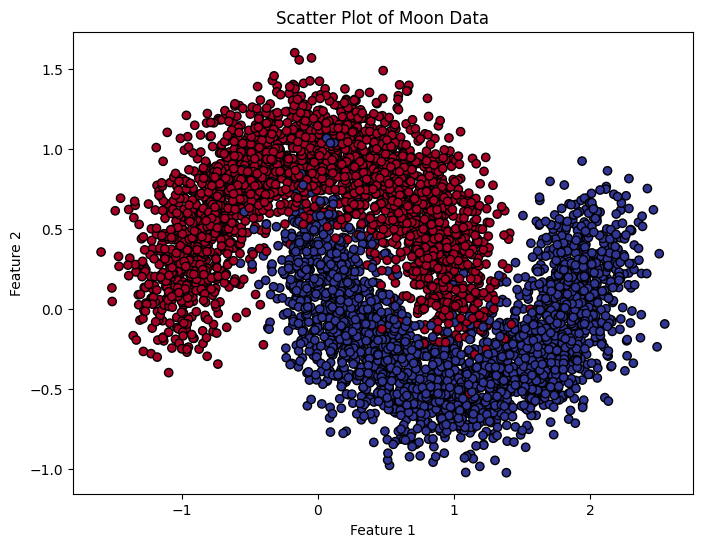

In [15]:
#Q 1

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k')
plt.title("Scatter Plot of Moon Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [16]:
#Q 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#Q 3

param_grid = {'n_neighbors': np.arange(1, 31)}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 1, 2..., 28, 29, 30])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(26)


In [18]:
#Q 4


cv_results_df = pd.DataFrame(grid_search.cv_results_)
output_df = cv_results_df[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]
print(output_df.sort_values(by='rank_test_score'))

    param_n_neighbors  mean_test_score  rank_test_score
25                 26          0.97125                1
26                 27          0.97100                2
24                 25          0.97100                3
22                 23          0.97100                3
19                 20          0.97100                3
23                 24          0.97050                6
21                 22          0.97025                7
18                 19          0.97025                7
15                 16          0.97025                7
20                 21          0.97000               10
16                 17          0.97000               10
27                 28          0.96975               12
17                 18          0.96975               12
14                 15          0.96950               14
29                 30          0.96925               15
28                 29          0.96925               15
9                  10          0.96900          

In [19]:
#Q 5
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
print(f"Best estimator: {best_model}")

Best parameters: {'n_neighbors': np.int64(26)}
Best estimator: KNeighborsClassifier(n_neighbors=np.int64(26))


In [20]:
#Q 6
y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy}")

Test Set Accuracy: 0.962


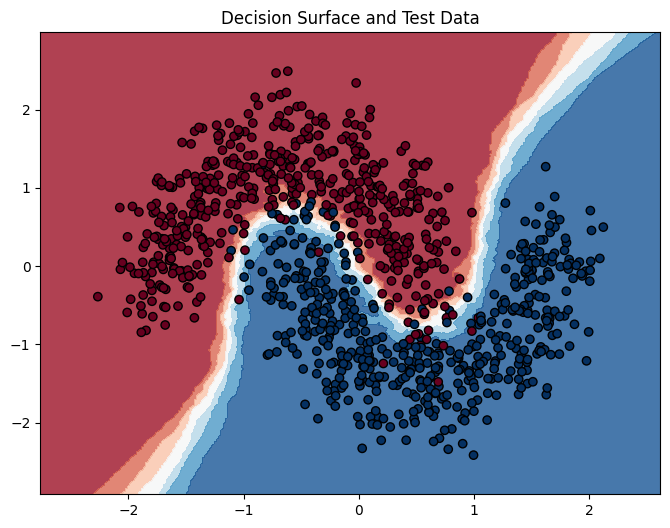

In [21]:
#Q 7
h = .02
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = best_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='RdBu', alpha=0.8)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolors='k', cmap='RdBu')
plt.title("Decision Surface and Test Data")
plt.show()